# SMS Spam Classifier with Security Risk Scoring

## Project Overview
This notebook builds a machine learning-based SMS spam classifier using the UCI SMS Spam Collection dataset. The model uses TF-IDF vectorization and compares Multinomial Naive Bayes with Logistic Regression for binary classification (spam vs. ham). The project includes a security risk scoring system that identifies suspicious patterns and suspicious words in SMS messages.

### Key Features:
- **Data Preprocessing**: Text cleaning, label encoding, train-test split
- **TF-IDF Vectorization**: Convert SMS text to numerical features
- **Machine Learning Models**: Multinomial Naive Bayes and Logistic Regression
- **Performance Metrics**: Accuracy, Precision, Recall, F1-Score, Confusion Matrix
- **Security Risk Scoring**: Flag suspicious words, links, and punctuation patterns
- **Prediction Demo**: Combined model predictions with confidence and risk scores

### Dataset:
- **Total Messages**: 5,574 SMS messages
- **Ham (Legitimate)**: 4,827 (86.6%)
- **Spam**: 747 (13.4%)
- **Source**: UCI SMS Spam Collection v.1

In [71]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import re
import warnings
import joblib
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


# SMS Spam Classifier with Security Risk Scoring

## Project Overview
This notebook builds a machine learning-based SMS spam classifier using the UCI SMS Spam Collection dataset. The model uses TF-IDF vectorization and compares Multinomial Naive Bayes with Logistic Regression for binary classification (spam vs. ham). The project includes a security risk scoring system that identifies suspicious patterns and suspicious words in SMS messages.

### Key Features:
- **Data Preprocessing**: Text cleaning, label encoding, train-test split
- **TF-IDF Vectorization**: Convert SMS text to numerical features
- **Machine Learning Models**: Multinomial Naive Bayes and Logistic Regression
- **Performance Metrics**: Accuracy, Precision, Recall, F1-Score, Confusion Matrix
- **Security Risk Scoring**: Flag suspicious words, links, and punctuation patterns
- **Prediction Demo**: Combined model predictions with confidence and risk scores

### Dataset:
- **Total Messages**: 5,574 SMS messages
- **Ham (Legitimate)**: 4,827 (86.6%)
- **Spam**: 747 (13.4%)
- **Source**: UCI SMS Spam Collection v.1

## 1. Load and Inspect the SMS Spam Dataset

Load the UCI SMS Spam Collection dataset into a DataFrame, inspect the schema, check class balance, and verify that there are no missing values or malformed rows.

Dataset Shape: (5572, 2)

First 5 rows of the dataset:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Information:
Total Messages: 5572
Number of Features: 2
Data Types:
label      str
message    str
dtype: object

Missing Values Check:
label      0
message    0
dtype: int64

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentage Distribution:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


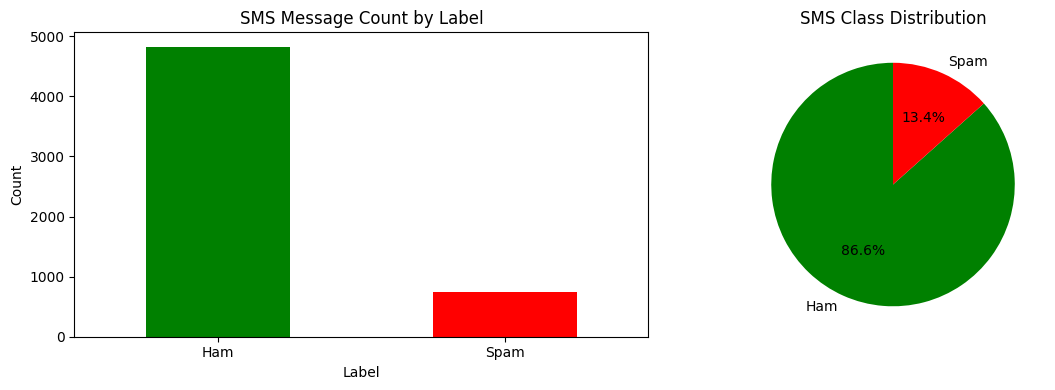


Message Length Analysis:
Average message length: 80.49 characters
Shortest message: 2 characters
Longest message: 910 characters

Message length statistics by class:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482902  58.442635   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


In [72]:
# Load the SMS Spam Collection dataset
# The dataset has two columns: label (ham/spam) and message text
# They are separated by a tab character

df = pd.read_csv(r'sms+spam+collection\SMSSpamCollection', sep='\t', names=['label', 'message'])

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\n" + "="*50)
print("Dataset Information:")
print("="*50)
print(f"Total Messages: {len(df)}")
print(f"Number of Features: {df.shape[1]}")
print(f"Data Types:\n{df.dtypes}")

print("\n" + "="*50)
print("Missing Values Check:")
print("="*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("Class Distribution:")
print("="*50)
class_dist = df['label'].value_counts()
print(class_dist)
print(f"\nPercentage Distribution:")
print(df['label'].value_counts(normalize=True) * 100)

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
class_dist.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('SMS Message Count by Label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Ham', 'Spam'], rotation=0)

# Pie chart
axes[1].pie(class_dist.values, labels=['Ham', 'Spam'], autopct='%1.1f%%', 
            colors=['green', 'red'], startangle=90)
axes[1].set_title('SMS Class Distribution')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Message Length Analysis:")
print("="*50)
df['message_length'] = df['message'].apply(len)
print(f"Average message length: {df['message_length'].mean():.2f} characters")
print(f"Shortest message: {df['message_length'].min()} characters")
print(f"Longest message: {df['message_length'].max()} characters")
print(f"\nMessage length statistics by class:")
print(df.groupby('label')['message_length'].describe())

## 2. Clean and Preprocess Message Text

Normalize the SMS text by lowercasing, removing punctuation and extra whitespace, and applying light text cleaning for consistent model input.

In [73]:
def clean_text(text):
    """
    Clean SMS text by:
    - Converting to lowercase
    - Removing special characters (keeping only alphanumeric and spaces)
    - Removing extra whitespace
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters but keep spaces and alphanumeric
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to messages
print("Applying text cleaning...")
df['cleaned_message'] = df['message'].apply(clean_text)

# Display some examples of cleaning
print("\nExample of cleaning:")
print("-" * 80)
for i in range(3):
    print(f"\nOriginal: {df.iloc[i]['message']}")
    print(f"Cleaned: {df.iloc[i]['cleaned_message']}")

print("\n" + "="*50)
print("Preprocessing Summary:")
print("="*50)
print(f"Total messages processed: {len(df)}")
print(f"Average cleaned message length: {df['cleaned_message'].apply(len).mean():.2f} characters")
print("Text cleaning completed successfully!")

Applying text cleaning...

Example of cleaning:
--------------------------------------------------------------------------------

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

Original: Ok lar... Joking wif u oni...
Cleaned: ok lar joking wif u oni

Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned: free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt ratetcs apply 08452810075over18s

Preprocessing Summary:
Total messages processed: 5572
Average cleaned message length: 75.44 characters
Text cleaning completed successfully!


## 3. Encode Labels and Split Data

Convert spam and ham labels into numeric targets (0 for ham, 1 for spam), then split the dataset into training and testing sets with a fixed random seed for reproducibility.

In [74]:
# Encode labels: ham = 0, spam = 1
df['label_encoded'] = (df['label'] == 'spam').astype(int)

print("Label Encoding Mapping:")
print("  ham  -> 0")
print("  spam -> 1")

print("\nLabel Distribution After Encoding:")
print(df['label_encoded'].value_counts().sort_index())

# Prepare data for splitting
X = df['cleaned_message']  # Features (cleaned messages)
y = df['label_encoded']    # Target (encoded labels)

# Split data into training (80%) and testing (20%) sets
# Using a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% for testing, 80% for training
    random_state=42,         # Fixed seed for reproducibility
    stratify=y               # Maintain class distribution in both sets
)

print("\n" + "="*50)
print("Train-Test Split Results:")
print("="*50)
print(f"Training set size: {len(X_train)} messages")
print(f"Testing set size: {len(X_test)} messages")
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)
print(f"\nTesting set class distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

print("\nData split completed successfully!")

Label Encoding Mapping:
  ham  -> 0
  spam -> 1

Label Distribution After Encoding:
label_encoded
0    4825
1     747
Name: count, dtype: int64

Train-Test Split Results:
Training set size: 4457 messages
Testing set size: 1115 messages

Training set class distribution:
label_encoded
0    86.582903
1    13.417097
Name: proportion, dtype: float64

Testing set class distribution:
label_encoded
0    86.636771
1    13.363229
Name: proportion, dtype: float64

Data split completed successfully!


## 4. Build TF-IDF Feature Pipeline

Transform SMS messages into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization, and fit the vectorizer on training data before transforming test data.

In [75]:
# Initialize TF-IDF Vectorizer
# Parameters:
# - max_features: Limit to 3000 most frequent terms for efficiency
# - stop_words: Remove common English stop words (the, a, an, etc.)
# - ngram_range: Use unigrams and bigrams (single words and word pairs)

tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2),
    lowercase=True
)

print("Fitting TF-IDF Vectorizer on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
print(f"✓ Training TF-IDF shape: {X_train_tfidf.shape}")

print("Transforming test data using the fitted vectorizer...")
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print(f"✓ Testing TF-IDF shape: {X_test_tfidf.shape}")

print("\n" + "="*50)
print("TF-IDF Vectorizer Information:")
print("="*50)
print(f"Number of features created: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"Maximum features allowed: 3000")
print(f"N-gram range: (1, 2) - unigrams and bigrams")
print(f"Stop words: English common words")

# Display some top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample of top features (first 20):")
print(list(feature_names[:20]))

print("\nTF-IDF vectorization completed successfully!")

Fitting TF-IDF Vectorizer on training data...
✓ Training TF-IDF shape: (4457, 3000)
Transforming test data using the fitted vectorizer...
✓ Testing TF-IDF shape: (1115, 3000)

TF-IDF Vectorizer Information:
Number of features created: 3000
Maximum features allowed: 3000
N-gram range: (1, 2) - unigrams and bigrams
Stop words: English common words

Sample of top features (first 20):
['0800', '0800 542', '08000839402', '08000930705', '08000930705 delivery', '08001950382', '0870', '0870 national', '08707509020', '08707509020 just', '08712300220', '08712300220 quoting', '08712460324', '08715705022', '08718720201', '09050090044', '09050090044 toclaim', '10', '100', '100 free']

TF-IDF vectorization completed successfully!


## 5. Train Multinomial Naive Bayes Model

Train a Multinomial Naive Bayes classifier on the TF-IDF features and generate predictions for the test set. Naive Bayes is ideal for text classification tasks.

In [76]:
# Train Multinomial Naive Bayes Model
print("Training Multinomial Naive Bayes Model...")
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)
print("✓ Model training completed!")

# Generate predictions on test set
print("\nGenerating predictions on test set...")
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"✓ Predictions generated! Total predictions: {len(y_pred_nb)}")

# Get prediction probabilities for confidence scores
y_pred_proba_nb = nb_model.predict_proba(X_test_tfidf)
print(f"✓ Probability scores generated!")

print("\n" + "="*50)
print("Naive Bayes Model Training Summary:")
print("="*50)
print(f"Model: Multinomial Naive Bayes")
print(f"Training samples: {X_train_tfidf.shape[0]}")
print(f"Number of features: {X_train_tfidf.shape[1]}")
print(f"Number of classes: {len(nb_model.classes_)}")
print(f"Classes: {nb_model.classes_}")

# Display prediction distribution
print(f"\nPrediction Distribution on Test Set:")
unique, counts = np.unique(y_pred_nb, return_counts=True)
for label, count in zip(unique, counts):
    label_name = "SPAM" if label == 1 else "HAM"
    percentage = (count / len(y_pred_nb)) * 100
    print(f"  {label_name} (class {label}): {count} ({percentage:.1f}%)")

print("\nNaive Bayes model training completed!")

Training Multinomial Naive Bayes Model...
✓ Model training completed!

Generating predictions on test set...
✓ Predictions generated! Total predictions: 1115
✓ Probability scores generated!

Naive Bayes Model Training Summary:
Model: Multinomial Naive Bayes
Training samples: 4457
Number of features: 3000
Number of classes: 2
Classes: [0 1]

Prediction Distribution on Test Set:
  HAM (class 0): 1000 (89.7%)
  SPAM (class 1): 115 (10.3%)

Naive Bayes model training completed!


## 6. Compare with Logistic Regression

Train a Logistic Regression baseline on the same feature set and compare its behavior and performance with the Naive Bayes model.

In [77]:
# Train Logistic Regression Model
print("Training Logistic Regression Model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
print("✓ Model training completed!")

# Generate predictions on test set
print("\nGenerating predictions on test set...")
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"✓ Predictions generated! Total predictions: {len(y_pred_lr)}")

# Get prediction probabilities
y_pred_proba_lr = lr_model.predict_proba(X_test_tfidf)
print(f"✓ Probability scores generated!")

print("\n" + "="*50)
print("Logistic Regression Model Training Summary:")
print("="*50)
print(f"Model: Logistic Regression")
print(f"Training samples: {X_train_tfidf.shape[0]}")
print(f"Number of features: {X_train_tfidf.shape[1]}")
print(f"Number of classes: {len(lr_model.classes_)}")
print(f"Classes: {lr_model.classes_}")

# Display prediction distribution
print(f"\nPrediction Distribution on Test Set:")
unique, counts = np.unique(y_pred_lr, return_counts=True)
for label, count in zip(unique, counts):
    label_name = "SPAM" if label == 1 else "HAM"
    percentage = (count / len(y_pred_lr)) * 100
    print(f"  {label_name} (class {label}): {count} ({percentage:.1f}%)")

print("\nLogistic Regression model training completed!")

Training Logistic Regression Model...
✓ Model training completed!

Generating predictions on test set...
✓ Predictions generated! Total predictions: 1115
✓ Probability scores generated!

Logistic Regression Model Training Summary:
Model: Logistic Regression
Training samples: 4457
Number of features: 3000
Number of classes: 2
Classes: [0 1]

Prediction Distribution on Test Set:
  HAM (class 0): 999 (89.6%)
  SPAM (class 1): 116 (10.4%)

Logistic Regression model training completed!


## 7. Evaluate Classification Performance

Compute accuracy, precision, recall, F1-score, and a confusion matrix to measure how well the models detect spam and avoid false positives.


EVALUATION METRICS - Multinomial Naive Bayes
Accuracy:   0.9695 (96.95%)
Precision:  1.0000 (100.00%)
Recall:     0.7718 (77.18%)
F1-Score:   0.8712

CONFUSION MATRIX
True Negatives (TN):  966
False Positives (FP): 0
False Negatives (FN): 34
True Positives (TP):  115

EVALUATION METRICS - Logistic Regression
Accuracy:   0.9704 (97.04%)
Precision:  1.0000 (100.00%)
Recall:     0.7785 (77.85%)
F1-Score:   0.8755

CONFUSION MATRIX
True Negatives (TN):  966
False Positives (FP): 0
False Negatives (FN): 33
True Positives (TP):  116


MODEL COMPARISON

    Metric  Naive Bayes  Logistic Regression
 Accuracy     0.969507             0.970404
Precision     1.000000             1.000000
   Recall     0.771812             0.778523
 F1-Score     0.871212             0.875472


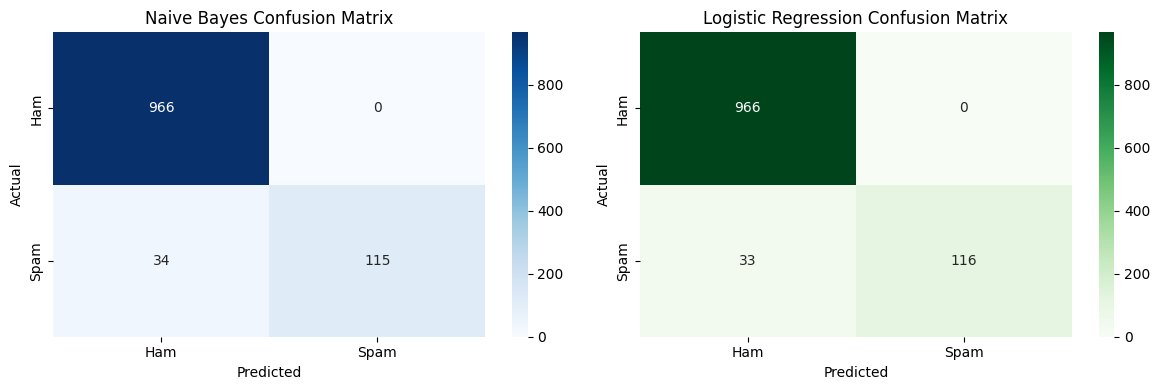


DETAILED CLASSIFICATION REPORT - NAIVE BAYES
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


DETAILED CLASSIFICATION REPORT - LOGISTIC REGRESSION
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [78]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate classification model using standard metrics
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"EVALUATION METRICS - {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:   {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision:  {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:     {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:   {f1:.4f}")
    
    print(f"\n{'='*60}")
    print("CONFUSION MATRIX")
    print(f"{'='*60}")
    cm = confusion_matrix(y_true, y_pred)
    print(f"True Negatives (TN):  {cm[0, 0]:,}")
    print(f"False Positives (FP): {cm[0, 1]:,}")
    print(f"False Negatives (FN): {cm[1, 0]:,}")
    print(f"True Positives (TP):  {cm[1, 1]:,}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

# Evaluate Naive Bayes Model
nb_results = evaluate_model(y_test, y_pred_nb, "Multinomial Naive Bayes")

# Evaluate Logistic Regression Model
lr_results = evaluate_model(y_test, y_pred_lr, "Logistic Regression")

# Model Comparison
print("\n\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [nb_results['accuracy'], nb_results['precision'], 
                    nb_results['recall'], nb_results['f1']],
    'Logistic Regression': [lr_results['accuracy'], lr_results['precision'], 
                            lr_results['recall'], lr_results['f1']]
})

print("\n", comparison_df.to_string(index=False))

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Naive Bayes Confusion Matrix
sns.heatmap(nb_results['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=axes[0])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Logistic Regression Confusion Matrix
sns.heatmap(lr_results['confusion_matrix'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Detailed Classification Reports
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT - NAIVE BAYES")
print("="*60)
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("="*60)
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))

## 8. Implement Security Risk Scoring and Prediction Demo

Create a risk scoring function that flags suspicious words, links, and excessive punctuation, then combine model prediction, confidence, risk level, and reason flags in example SMS classifications.

In [79]:
# Security Risk Scoring System
class SecurityRiskScorer:
    """
    Analyzes SMS messages for security risk factors including:
    - Suspicious/trigger words common in spam
    - Links and URLs
    - Excessive punctuation
    - All caps text
    - Phone numbers and monetary values
    """
    
    def __init__(self):
        # Suspicious words commonly found in spam messages
        self.suspicious_words = {
            'free': 2, 'win': 2, 'winner': 3, 'cash': 2, 'prize': 3,
            'claim': 2, 'click': 2, 'urgent': 2, 'click here': 3,
            'call': 1, 'reply': 1, 'text': 1, 'confirm': 1,
            'verify': 2, 'update': 1, 'congratulations': 2,
            'million': 3, 'guaranteed': 2, 'limited': 1,
            'offer': 1, 'deal': 1, 'act now': 2, 'hurry': 1,
            'bonus': 2, 'reward': 2, 'loan': 2, 'credit': 1
        }
    
    def score_message(self, message):
        """
        Calculate risk score (0-10) and identify risk flags
        """
        message_lower = message.lower()
        risk_score = 0
        risk_flags = []
        
        # Check for suspicious words
        for word, weight in self.suspicious_words.items():
            if word in message_lower:
                risk_score += weight
                if word not in [f.split('(')[0].strip() for f in risk_flags]:
                    risk_flags.append(f"Suspicious word: '{word}'")
        
        # Check for URLs
        url_pattern = r'http\S+|www\S+|https\S+|\.[a-z]{2,}'
        if re.search(url_pattern, message_lower):
            risk_score += 3
            risk_flags.append("URL or link detected")
        
        # Check for phone numbers
        phone_pattern = r'\b[\d\s\-\+\(\)]{8,}\b'
        if re.search(phone_pattern, message):
            risk_score += 2
            risk_flags.append("Phone number detected")
        
        # Check for monetary values
        money_pattern = r'\$\d+|£\d+|€\d+|\d+\s*(dollars|pounds|euros|gbp)'
        if re.search(money_pattern, message_lower):
            risk_score += 2
            risk_flags.append("Monetary value mentioned")
        
        # Check for excessive punctuation
        total_chars = len(message)
        if total_chars > 0:
            exclamation_ratio = message.count('!') / total_chars
            question_ratio = message.count('?') / total_chars
            if exclamation_ratio > 0.05:
                risk_score += 1
                risk_flags.append("Excessive exclamation marks")
            if question_ratio > 0.05:
                risk_score += 1
                risk_flags.append("Excessive question marks")
        
        # Check for all caps
        if len(message) > 5:
            caps_ratio = sum(1 for c in message if c.isupper()) / len(message)
            if caps_ratio > 0.5:
                risk_score += 1
                risk_flags.append("Excessive capitalization")
        
        # Cap the risk score at 10
        risk_score = min(risk_score, 10)
        
        # Determine risk level
        if risk_score >= 7:
            risk_level = "HIGH"
        elif risk_score >= 4:
            risk_level = "MEDIUM"
        elif risk_score >= 1:
            risk_level = "LOW"
        else:
            risk_level = "NONE"
        
        return {
            'risk_score': risk_score,
            'risk_level': risk_level,
            'risk_flags': risk_flags if risk_flags else ["No red flags detected"]
        }

# Initialize the risk scorer
risk_scorer = SecurityRiskScorer()

def predict_and_score_message(message, use_naive_bayes=True):
    """
    Make a complete prediction for a message including:
    - Model prediction (spam/ham)
    - Confidence score
    - Security risk score
    - Reason flags
    """
    # Clean the message
    cleaned_msg = clean_text(message)
    
    # Convert to TF-IDF
    msg_tfidf = tfidf_vectorizer.transform([cleaned_msg])
    
    # Get model prediction
    if use_naive_bayes:
        prediction = nb_model.predict(msg_tfidf)[0]
        confidence = nb_model.predict_proba(msg_tfidf)[0]
    else:
        prediction = lr_model.predict(msg_tfidf)[0]
        confidence = lr_model.predict_proba(msg_tfidf)[0]
    
    # Get security risk score
    risk_info = risk_scorer.score_message(message)
    
    prediction_label = "SPAM" if prediction == 1 else "HAM"
    confidence_score = max(confidence) * 100
    
    return {
        'original_message': message,
        'cleaned_message': cleaned_msg,
        'prediction': prediction_label,
        'confidence': confidence_score,
        'risk_score': risk_info['risk_score'],
        'risk_level': risk_info['risk_level'],
        'risk_flags': risk_info['risk_flags']
    }

# Example predictions
print("="*80)
print("SMS SPAM CLASSIFIER WITH SECURITY RISK SCORING - DEMONSTRATION")
print("="*80)

# Test messages
test_messages = [
    "Hi, how are you doing today?",
    "FreeMsg: Txt: CALL to No: 86888 & claim your reward of 3 hours talk time!",
    "Hey John, want to grab coffee tomorrow?",
    "URGENT! Your mobile was awarded a L2,000 Bonus Prize! Click here NOW!",
    "Mom, I'll be home by 6pm. Love you!",
    "Win a FREE iPhone! Limited time offer! Click here: www.fake-site.com",
    "Just finished the project, sending it to you shortly.",
    "CONGRATULATIONS!!! You have WON a PRIZE!!! Call 123-456-7890 to CLAIM!!!",
]

results = []
for msg in test_messages:
    result = predict_and_score_message(msg, use_naive_bayes=True)
    results.append(result)
    
    print(f"\n{'='*80}")
    print(f"Original Message: {msg}")
    print(f"{'='*80}")
    print(f"Cleaned Message: {result['cleaned_message']}")
    print(f"\nModel Prediction: {result['prediction']}")
    print(f"Confidence Score: {result['confidence']:.2f}%")
    print(f"\nSecurity Risk Score: {result['risk_score']}/10")
    print(f"Risk Level: {result['risk_level']}")
    print(f"Risk Flags:")
    for flag in result['risk_flags']:
        print(f"  • {flag}")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Total predictions made: {len(results)}")
print(f"Spam detections (by model): {sum(1 for r in results if r['prediction'] == 'SPAM')}")
print(f"Ham detections (by model): {sum(1 for r in results if r['prediction'] == 'HAM')}")
print(f"\nAverage risk score: {np.mean([r['risk_score'] for r in results]):.2f}")
print("\nHigh-risk messages identified:")
high_risk = [r for r in results if r['risk_level'] == 'HIGH']
for i, r in enumerate(high_risk, 1):
    print(f"  {i}. \"{r['original_message'][:50]}...\" - Risk: {r['risk_level']}")

SMS SPAM CLASSIFIER WITH SECURITY RISK SCORING - DEMONSTRATION

Original Message: Hi, how are you doing today?
Cleaned Message: hi how are you doing today

Model Prediction: HAM
Confidence Score: 99.19%

Security Risk Score: 0/10
Risk Level: NONE
Risk Flags:
  • No red flags detected

Original Message: FreeMsg: Txt: CALL to No: 86888 & claim your reward of 3 hours talk time!
Cleaned Message: freemsg txt call to no 86888 claim your reward of 3 hours talk time

Model Prediction: SPAM
Confidence Score: 68.88%

Security Risk Score: 7/10
Risk Level: HIGH
Risk Flags:
  • Suspicious word: 'free'
  • Suspicious word: 'claim'
  • Suspicious word: 'call'
  • Suspicious word: 'reward'

Original Message: Hey John, want to grab coffee tomorrow?
Cleaned Message: hey john want to grab coffee tomorrow

Model Prediction: HAM
Confidence Score: 98.72%

Security Risk Score: 0/10
Risk Level: NONE
Risk Flags:
  • No red flags detected

Original Message: URGENT! Your mobile was awarded a L2,000 Bonus Prize! 

In [80]:
joblib.dump(nb_model, r'models\naive_bayes_model.joblib')
joblib.dump(lr_model, r'models\logistic_regression_model.joblib')

['models\\logistic_regression_model.joblib']